##FRAUD DETECTION ECOMMERCE MACHINE LEARNING

In [2]:
#Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)

In [3]:
#Dọc dữ liệu
df=pd.read_csv('E:\KimYen\FinalProject-20260309T134007Z-3-001\FinalProject\Fraudulent_E-Commerce_Transaction_Data.csv')

<>:2: SyntaxWarning: invalid escape sequence '\K'
<>:2: SyntaxWarning: invalid escape sequence '\K'
C:\Users\Admin\AppData\Local\Temp\ipykernel_13552\1627904032.py:2: SyntaxWarning: invalid escape sequence '\K'
  df=pd.read_csv('E:\KimYen\FinalProject-20260309T134007Z-3-001\FinalProject\Fraudulent_E-Commerce_Transaction_Data.csv')


In [9]:
#Kiểm tra một số thông tin tổng quan
print('Thông tin chung:')
df.info()
print('-'*50)
print('Kích thước tập dữ liệu:')
print(df.shape)
print('-'*50)
print('Định dạng các cột:')
df.dtypes



Thông tin chung:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1472952 entries, 0 to 1472951
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Transaction ID      1472952 non-null  object 
 1   Customer ID         1472952 non-null  object 
 2   Transaction Amount  1472952 non-null  float64
 3   Transaction Date    1472952 non-null  object 
 4   Payment Method      1472952 non-null  object 
 5   Product Category    1472952 non-null  object 
 6   Quantity            1472952 non-null  int64  
 7   Customer Age        1472952 non-null  int64  
 8   Customer Location   1472952 non-null  object 
 9   Device Used         1472952 non-null  object 
 10  IP Address          1472952 non-null  object 
 11  Shipping Address    1472952 non-null  object 
 12  Billing Address     1472952 non-null  object 
 13  Is Fraudulent       1472952 non-null  int64  
 14  Account Age Days    1472952 non-null  int64  
 15

Transaction ID         object
Customer ID            object
Transaction Amount    float64
Transaction Date       object
Payment Method         object
Product Category       object
Quantity                int64
Customer Age            int64
Customer Location      object
Device Used            object
IP Address             object
Shipping Address       object
Billing Address        object
Is Fraudulent           int64
Account Age Days        int64
Transaction Hour        int64
dtype: object

##I/ Data Dictionary

##Chi tiết các cột:
- Transaction ID: Mã giao dịch
- Customer ID: Mã khách hàng
- Transaction Amount: Số tiền giao dịch
- Transaction Date: Ngày giờ giao dịch
- Payment Method: Phương thức giao dịch
- Product Category: Danb mục sản phẩm giao dịch
- Quantity: Số lượng sản phẩm tham gia giao dịch
- Customer Age: Tuổi khách hàng
- Customer Location: Vị trí địa lý của khách hàng
- Device Used: Thiết bị sử dung để giao dịch
- IP Address: Địa chỉ IP của thiết bị sử dụng giao dịch
- Shipping Address: Địa chỉ giao hàng
- Billing AddressL Địa chỉ trên háo đơn
- Is Fraudulent: 1 - Fraudulent, 0 - None Fraudulent
- Account Age Days: Tuổi tài khoản khách hàng (tính theo ngày)
- Transaction Hour: Giờ giao dịch

#II/ Thông tin tổng quan

In [10]:
#In 5 dòng đầu dữ liệu
df.head()


,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,2024-02-20 05:58:41,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,5
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,2024-02-25 08:09:45,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,8
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,2024-03-18 03:42:55,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,3
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,2024-03-16 20:41:31,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,2024-01-15 05:08:17,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, OH 36093","29799 Jason Hills Apt. 439\nWest Richardtown, OH 36093",0,158,5


In [11]:
#Xem thông số diễn tả
df.describe()

,Transaction Amount,Quantity,Customer Age,Is Fraudulent,Account Age Days,Transaction Hour
count,1.472952e+06,1.472952e+06,1.472952e+06,1.472952e+06,1.472952e+06,1.472952e+06
mean,2.267683e+02,3.000230e+00,3.451208e+01,5.012926e-02,1.796464e+02,1.128696e+01
std,2.703951e+02,1.414736e+00,1.000313e+01,2.182117e-01,1.068642e+02,6.975995e+00
min,1.000000e+01,1.000000e+00,-1.600000e+01,0.000000e+00,1.000000e+00,0.000000e+00
25%,6.861000e+01,2.000000e+00,2.800000e+01,0.000000e+00,8.600000e+01,5.000000e+00
50%,1.517600e+02,3.000000e+00,3.500000e+01,0.000000e+00,1.790000e+02,1.100000e+01
75%,2.960500e+02,4.000000e+00,4.100000e+01,0.000000e+00,2.720000e+02,1.700000e+01
max,1.270175e+04,5.000000e+00,8.600000e+01,1.000000e+00,3.650000e+02,2.300000e+01


##Một số thông tin:
- Transaction Amout có max tương đương 12,701, meadian chỉ tương đương 151. Chênh lệch max, min khá lệch để phân tích
- Customer Age: xuất hiện giá trị âm của min =>bấtt hợp lý

In [12]:
#Xem tương quan
df.corr(numeric_only=True)

,Transaction Amount,Quantity,Customer Age,Is Fraudulent,Account Age Days,Transaction Hour
Transaction Amount,1.000000,-0.000652,0.000292,0.272766,-0.035733,-0.029909
Quantity,-0.000652,1.000000,0.000803,-0.001027,0.001212,0.000060
Customer Age,0.000292,0.000803,1.000000,-0.001129,0.000545,0.001311
Is Fraudulent,0.272766,-0.001027,-0.001129,1.000000,-0.136188,-0.112821
Account Age Days,-0.035733,0.001212,0.000545,-0.136188,1.000000,0.016409
Transaction Hour,-0.029909,0.000060,0.001311,-0.112821,0.016409,1.000000


<Axes: >

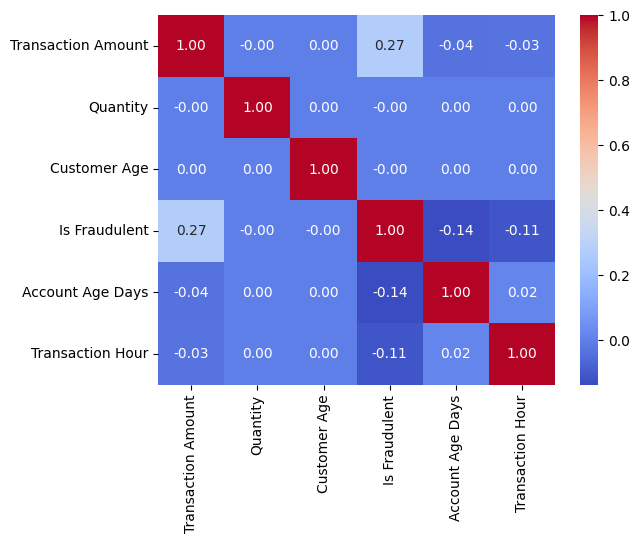

In [13]:
#biểu dồ heatmap tương quan
sns.heatmap(df.corr(numeric_only=True),fmt='.2f',annot=True,cmap='coolwarm')

##Một số thông tin:
- Giao dịch có giá trị(transaction Amout) cao thì có xu hướng Fraud nhiều (tương quan +0.27)
- Quantity,Customer Age: hầu như không có quan hệ tuyến tính với Fraud
- Account Age Days: Tài khoản càng lâu thì xu hướng Fraude ít hơn (-0.14)
- Transaction Hour: Ở khung giờ càng sớm thì fraud xảy ra nhiều hơn (-0.11)


#III/Kiểm tra và tiền xử lý dữ liệu

In [14]:
# Kiểm tra giá trị null
df.isnull().sum().to_frame().T

,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [15]:
#Kiểm tra giá trị null
df.isnull().sum()

Transaction ID        0
Customer ID           0
Transaction Amount    0
Transaction Date      0
Payment Method        0
Product Category      0
Quantity              0
Customer Age          0
Customer Location     0
Device Used           0
IP Address            0
Shipping Address      0
Billing Address       0
Is Fraudulent         0
Account Age Days      0
Transaction Hour      0
dtype: int64

In [16]:
#Kiểm tra giá trị trùng lặp
df.duplicated().sum()

np.int64(0)

#XỬ LÝ DỮ LIỆU

In [4]:
#Chuẩn hoá định dạng cột transaction day từ object thành datetime
df['Transaction Date']=pd.to_datetime(df['Transaction Date'])

In [5]:
#Xem tỷ lệ gía trị âm của cột Customer Age
df[df['Customer Age']<0].shape[0]/df.shape[0]


0.00017515845730207093

### Xử lý cột Transaction Amout đưa về gía trị log1


In [6]:
#Xử lý cột Transaction Amout đưa về gía trị log1
df['Log Transaction Amount']=np.log1p(df['Transaction Amount'])

###Xử lý cột Customer Age có số âm

In [7]:
#1/ Tạo cột Customer Age Raw từ cột Cusrtomer Age
df['Customer Age Raw']=df['Customer Age']

In [8]:
#2/ Gắn nhãn 0 và 1 cho cột Customer Age Raw đê mô hình nhận biết dữ liệu gốc nào có tuổi âm (với 1:gốc có giá trị âm)
df['Age Invalid']=(df['Customer Age Raw']<0).astype(int)
print(df['Age Invalid'].value_counts())

Age Invalid
0    1472694
1        258
Name: count, dtype: int64


In [9]:
#3/ Tính trung vị tuổi dựa trên các giá trị dương của cột Customer Age Raw
median_age=df[df['Customer Age Raw']>0]['Customer Age Raw'].median()


In [11]:
# 4/ Tạo cột Customer Age Clean từ cột Customer Age Raw với các giá trị âm thay bằng giá trị median_age
df['Customer Age Clean']=np.where(df['Customer Age Raw']<0,median_age,df['Customer Age Raw'])

###Xử lý cột Transaction Date

In [12]:
#Tạo cột Transaction Day có gái trị là ngày trong tuần , định dạng kiểu Mon, Tues,...
df['Transaction Day'] = df['Transaction Date'].dt.strftime('%a')
df['Transaction Day'].value_counts()

Transaction Day
Tue    221151
Mon    219865
Wed    210313
Sun    205699
Fri    205431
Sat    205369
Thu    205124
Name: count, dtype: int64

In [13]:
#Tạo cột Transaction Month với giá trị tháng
df['Transaction Month'] = df['Transaction Date'].dt.month
df['Transaction Month'].value_counts()

Transaction Month
3    489221
1    489027
2    457863
4     36841
Name: count, dtype: int64

In [26]:
#Xem năm trong cột Trnsaction Date
df['Transaction Date'].dt.year.value_counts()


Transaction Date
2024    1472952
Name: count, dtype: int64

###Xử lý cột Shipping Adress và Billing Adress

In [14]:
#Tạo cột Ship_Bill_Match để xem những dòng có địa chỉ giao hàng và địa chỉ trên hoá đơn có trùng nhau không(không trùng thì khả năng rủ ro cao)
df['Ship_Bill_Match']=(df['Shipping Address']==df['Billing Address']).astype(int)
df['Ship_Bill_Match'].value_counts()

Ship_Bill_Match
1    1325429
0     147523
Name: count, dtype: int64

In [15]:
#Tỷ lệ Ship_Bill_Mathch = 0
print('Tỷ lệ địa chỉ không trùng nhau:',len(df['Ship_Bill_Match'][df['Ship_Bill_Match']==0])/len(df))

Tỷ lệ địa chỉ không trùng nhau: 0.10015465541307524


#Nhận xét:
- Dữ liệu nhìn chung sạch, các lỗi bất thường như Customer Age âm xuất hiện rất ít, xử lý gắn nhãn các giao dịch có tuổi âm để mô hình có thể học tốt hơn
- Việc biến đổi Transaction Amount bằng log1p là bước  giúp ổn định phân phối và tăng khả năng học của mô hình.
- Về thời gian, dữ liệu tập trung mạnh vào Q1/2024, biến đổi định dạng chuẩn theo thời gian
- Đáng chú ý, biến Ship/Bill mismatch (10%) là tín hiệu hành vi có khả năng  đóng góp đáng kể cho hiệu quả phát hiện fraud.

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1472952 entries, 0 to 1472951
Data columns (total 23 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   Transaction ID          1472952 non-null  object        
 1   Customer ID             1472952 non-null  object        
 2   Transaction Amount      1472952 non-null  float64       
 3   Transaction Date        1472952 non-null  datetime64[ns]
 4   Payment Method          1472952 non-null  object        
 5   Product Category        1472952 non-null  object        
 6   Quantity                1472952 non-null  int64         
 7   Customer Age            1472952 non-null  int64         
 8   Customer Location       1472952 non-null  object        
 9   Device Used             1472952 non-null  object        
 10  IP Address              1472952 non-null  object        
 11  Shipping Address        1472952 non-null  object        
 12  Billing Addres

###Tạo dữ liệu df_model để dùng cho việc train mô hình

In [16]:
df = df.sort_values(['Transaction Date', 'Transaction Hour']).reset_index(drop=True)

In [17]:
#) Drop các cột không cần đưa vào mô hình, tạo df_model
drop_column=['Transaction ID','Customer ID','Transaction Date','IP Address','Shipping Address','Billing Address','Customer Age','Customer Location','Customer Age Raw']


In [18]:
df_model=df.drop(columns=drop_column,errors='ignore')

In [33]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1472952 entries, 0 to 1472951
Data columns (total 14 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Transaction Amount      1472952 non-null  float64
 1   Payment Method          1472952 non-null  object 
 2   Product Category        1472952 non-null  object 
 3   Quantity                1472952 non-null  int64  
 4   Device Used             1472952 non-null  object 
 5   Is Fraudulent           1472952 non-null  int64  
 6   Account Age Days        1472952 non-null  int64  
 7   Transaction Hour        1472952 non-null  int64  
 8   Log Transaction Amount  1472952 non-null  float64
 9   Age Invalid             1472952 non-null  int64  
 10  Customer Age Clean      1472952 non-null  float64
 11  Transaction Day         1472952 non-null  object 
 12  Transaction Month       1472952 non-null  int32  
 13  Ship_Bill_Match         1472952 non-null  int64  
dtypes:

#IV/ Khảo sát dữ liệu

##1) Khảo sát nhãn dữ liệu

Số lượng hành khách Fraudulent: 73838
Số lượng hành khách không Fraudulent: 1399114


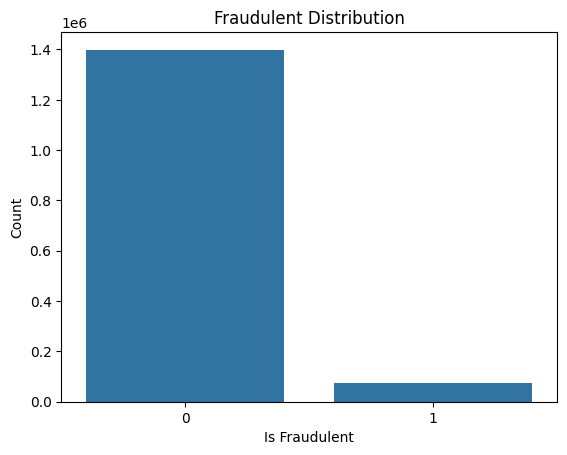

In [34]:
#Vẽ biểu đồ thể hiện số lượng Fraud
print('Số lượng hành khách Fraudulent:',len(df_model['Is Fraudulent'][df['Is Fraudulent']==1]))
print('Số lượng hành khách không Fraudulent:',len(df_model['Is Fraudulent'][df['Is Fraudulent']==0]))

sns.countplot(x='Is Fraudulent',data=df_model)
plt.xlabel('Is Fraudulent')
plt.ylabel('Count')
plt.title('Fraudulent Distribution')
plt.show()

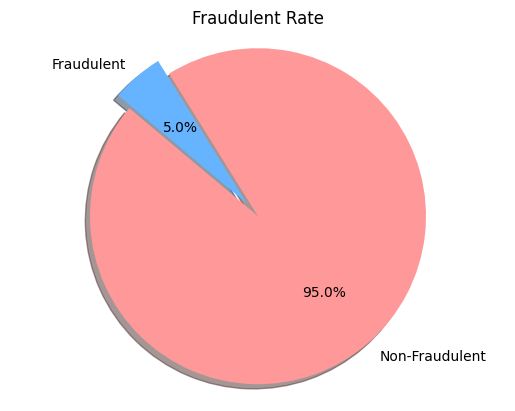

In [35]:
#Vẽ biểu đồ tròn thể hiện tỷ lệ fraud và non-fraud
labels = ['Non-Fraudulent', 'Fraudulent']
sizes = [len(df_model['Is Fraudulent'][df_model['Is Fraudulent']==0]), len(df_model['Is Fraudulent'][df_model['Is Fraudulent']==1])]
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0)
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')
plt.title('Fraudulent Rate')
plt.show()

In [36]:
#Tỷ lệ Fraud
print('Tỷ lệ Fraudulent:',len(df_model['Is Fraudulent'][df_model['Is Fraudulent']==1])/len(df_model))

Tỷ lệ Fraudulent: 0.05012926422585393


Phân phối nhãn cho thấy dữ liệu bị mất cân bằng mạnh, với Fraudulent khoảng 5% . Vì vậy, accuracy có thể gây hiểu nhầm (mô hình đoán toàn non-fraud vẫn đạt 95%). Trong báo cáo này, hiệu quả mô hình ta đánh giá chủ yếu bằng Precision, Recall, F1 và PR-AUC

In [37]:
#In giá trị unique của mỗi cột
df_model.nunique()

Transaction Amount        108998
Payment Method                 4
Product Category               5
Quantity                       5
Device Used                    3
Is Fraudulent                  2
Account Age Days             365
Transaction Hour              24
Log Transaction Amount    107760
Age Invalid                    2
Customer Age Clean            83
Transaction Day                7
Transaction Month              4
Ship_Bill_Match                2
dtype: int64

In [38]:
#Xem định dạng các cột
df_model.dtypes

Transaction Amount        float64
Payment Method             object
Product Category           object
Quantity                    int64
Device Used                object
Is Fraudulent               int64
Account Age Days            int64
Transaction Hour            int64
Log Transaction Amount    float64
Age Invalid                 int64
Customer Age Clean        float64
Transaction Day            object
Transaction Month           int32
Ship_Bill_Match             int64
dtype: object

In [20]:
#tìm các feature

target = 'Is Fraudulent'
X = df_model.drop(columns=[target])

num_cols = []
cat2_cols = []
cat_cols = []

for col in X.columns:
    nunq = X[col].nunique(dropna=True)
    dtype = X[col].dtype

    if dtype == 'object':
        cat_cols.append(col)
    else:
        # numeric
        if nunq <= 2:
            cat2_cols.append(col)
        elif nunq < 5:
            cat_cols.append(col)
        else:
            num_cols.append(col)

print('num_cols:', num_cols)
print('cat2_cols:', cat2_cols)
print('cat_cols:', cat_cols)

num_cols: ['Transaction Amount', 'Quantity', 'Account Age Days', 'Transaction Hour', 'Log Transaction Amount', 'Customer Age Clean']
cat2_cols: ['Age Invalid', 'Ship_Bill_Match']
cat_cols: ['Payment Method', 'Product Category', 'Device Used', 'Transaction Day', 'Transaction Month']


##Visualize các cột feature

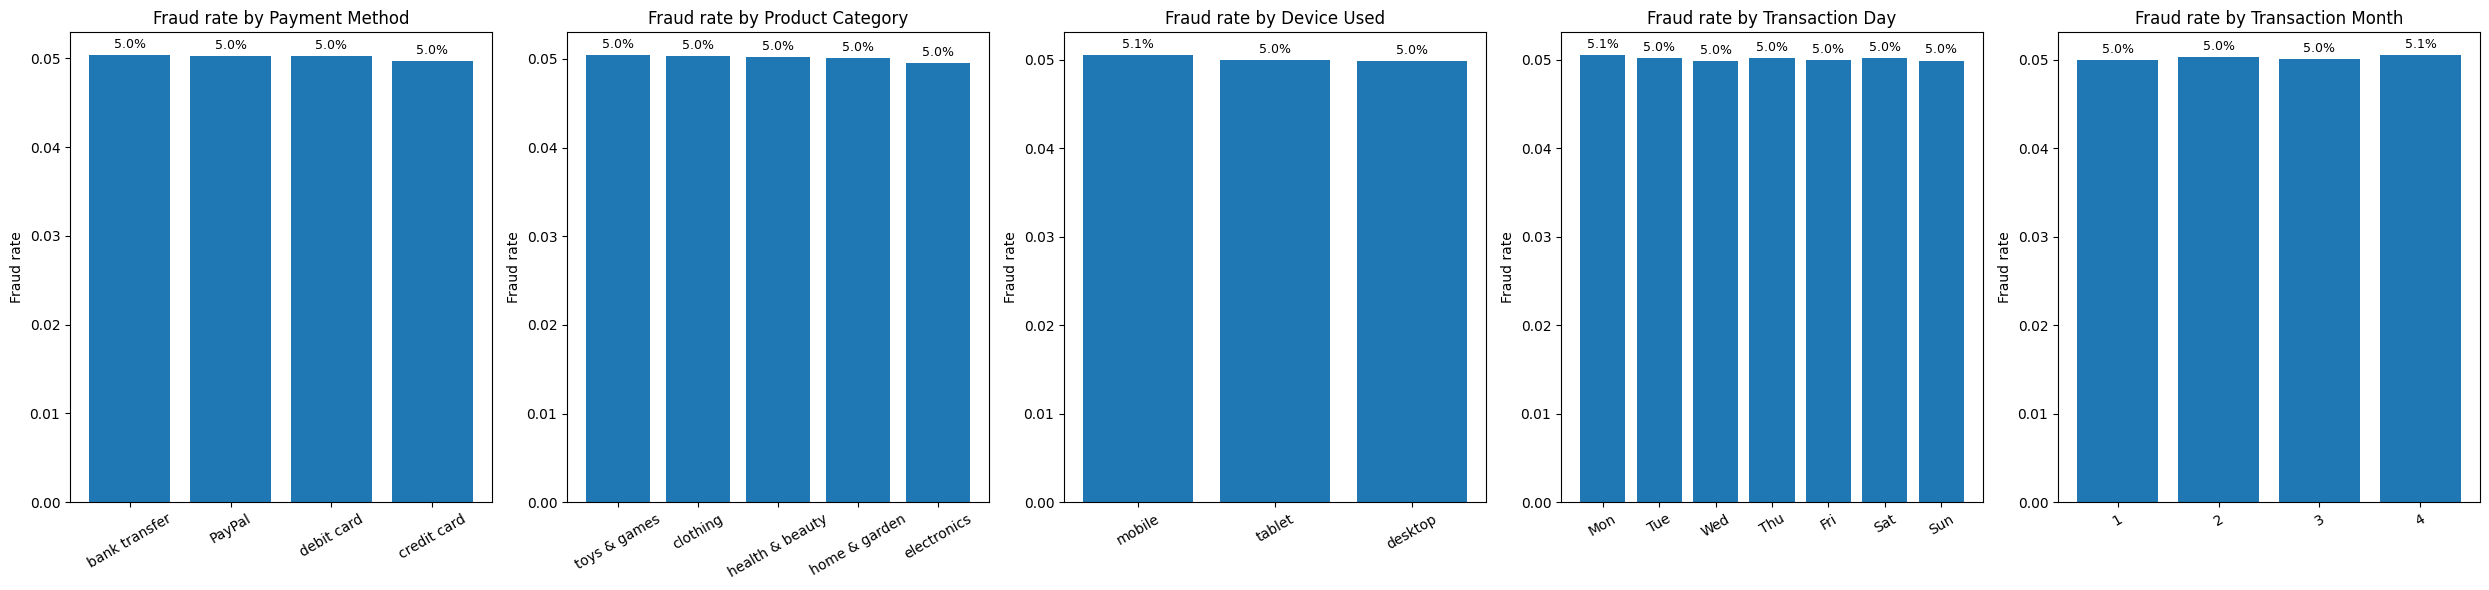

In [40]:
# Visualization các cột features dạng categories:
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
month_order = list(range(1, 13))

fig, axes = plt.subplots(1, 5, figsize=(25, 6))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    rate = (
        df_model.groupby(col)[target]
        .mean())

    if col == 'Transaction Day':
        rate = rate.reindex(day_order)
    elif col == 'Transaction Month':
        rate = rate.reindex(month_order)
    else:
        rate = rate.sort_values(ascending=False)


    bars = axes[i].bar(rate.index.astype(str), rate.values)
    axes[i].set_title(f'Fraud rate by {col}')
    axes[i].set_ylabel('Fraud rate')
    axes[i].tick_params(axis='x', rotation=30)

    axes[i].bar_label(bars, labels=[f'{v*100:.1f}%' for v in rate.values], padding=3, fontsize=9)

# Ẩn ô dư
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

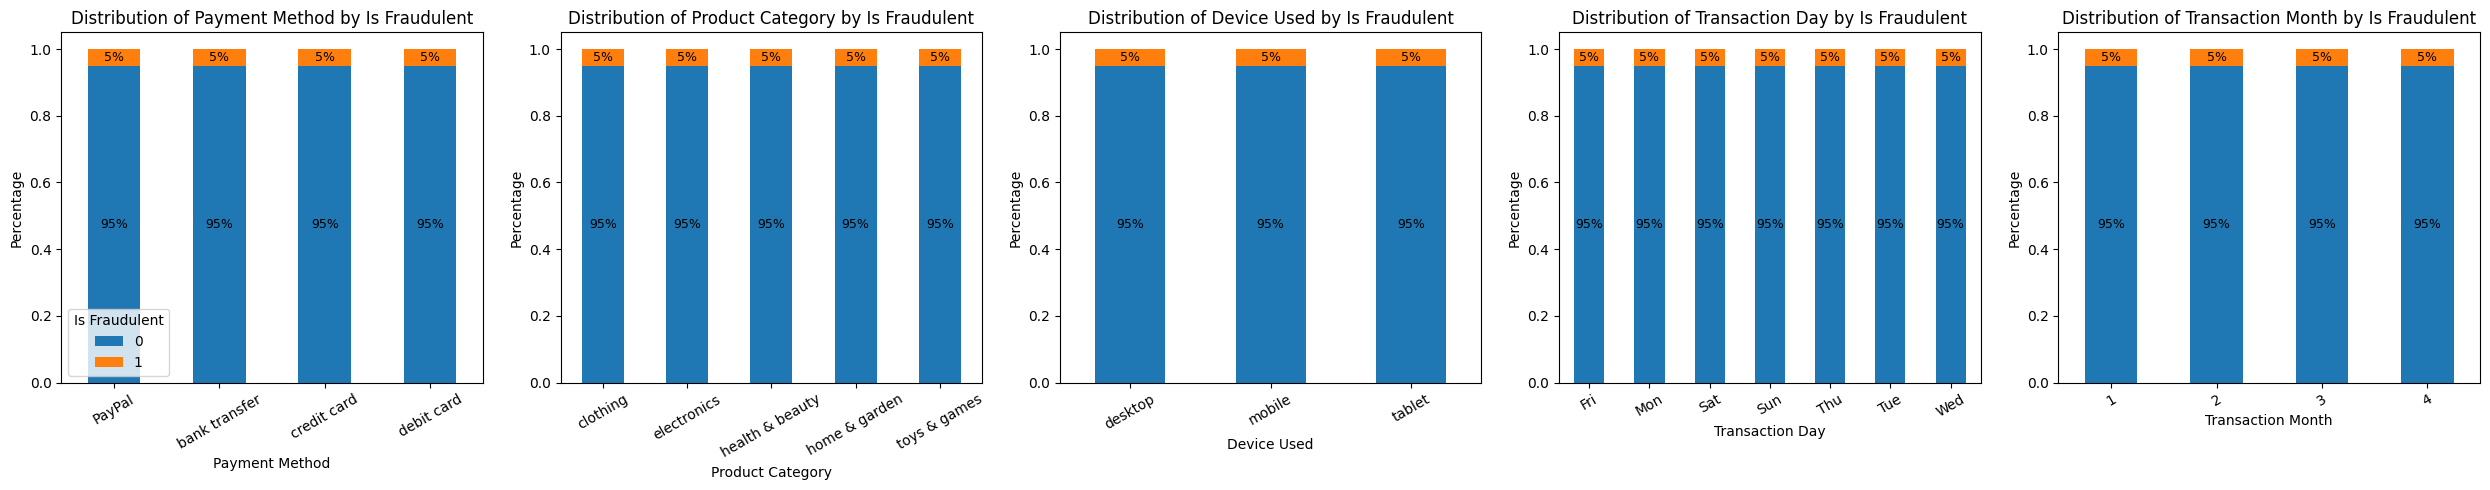

In [41]:
#Biểu đồ cột chồng
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
axes = axes.ravel()
for i,col in enumerate(cat_cols):
  tmp = df_model.groupby(col)['Is Fraudulent'].value_counts(normalize=True).unstack()
  tmp.plot(kind='bar', stacked=True, ax=axes[i], legend=(i==0))
  ax = axes[i]

  for container in ax.containers:
        ax.bar_label(
            container,
            labels=[f'{v*100:.0f}%' if v > 0 else '' for v in container.datavalues],
            label_type='center',
            fontsize=9)

  axes[i].set_title(f'Distribution of {col} by Is Fraudulent')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Percentage')
  axes[i].tick_params(axis='x', rotation=30)


plt.tight_layout()
plt.show()

#Nhận xét:

Tất cả các cột categorical đều có fraud rate ~5.0% gần như nhau.

Chênh lệch chỉ khoảng:

5.0%

5.1%

4.9%

=> Các feature thuộc nhóm Category hầu như như không phn biệt rõ ràng tỷ lệ Fraud, không mang nhiều ý nghĩa và tác động lắm đến việc dự đoán Fraud

In [42]:
num_cols

['Transaction Amount',
 'Quantity',
 'Account Age Days',
 'Transaction Hour',
 'Log Transaction Amount',
 'Customer Age Clean']

C:\Users\Admin\AppData\Local\Temp\ipykernel_5832\3233703357.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = tmp.groupby('bin')[target].agg(['mean','size'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_5832\3233703357.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = tmp.groupby('bin')[target].agg(['mean','size'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_5832\3233703357.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default a

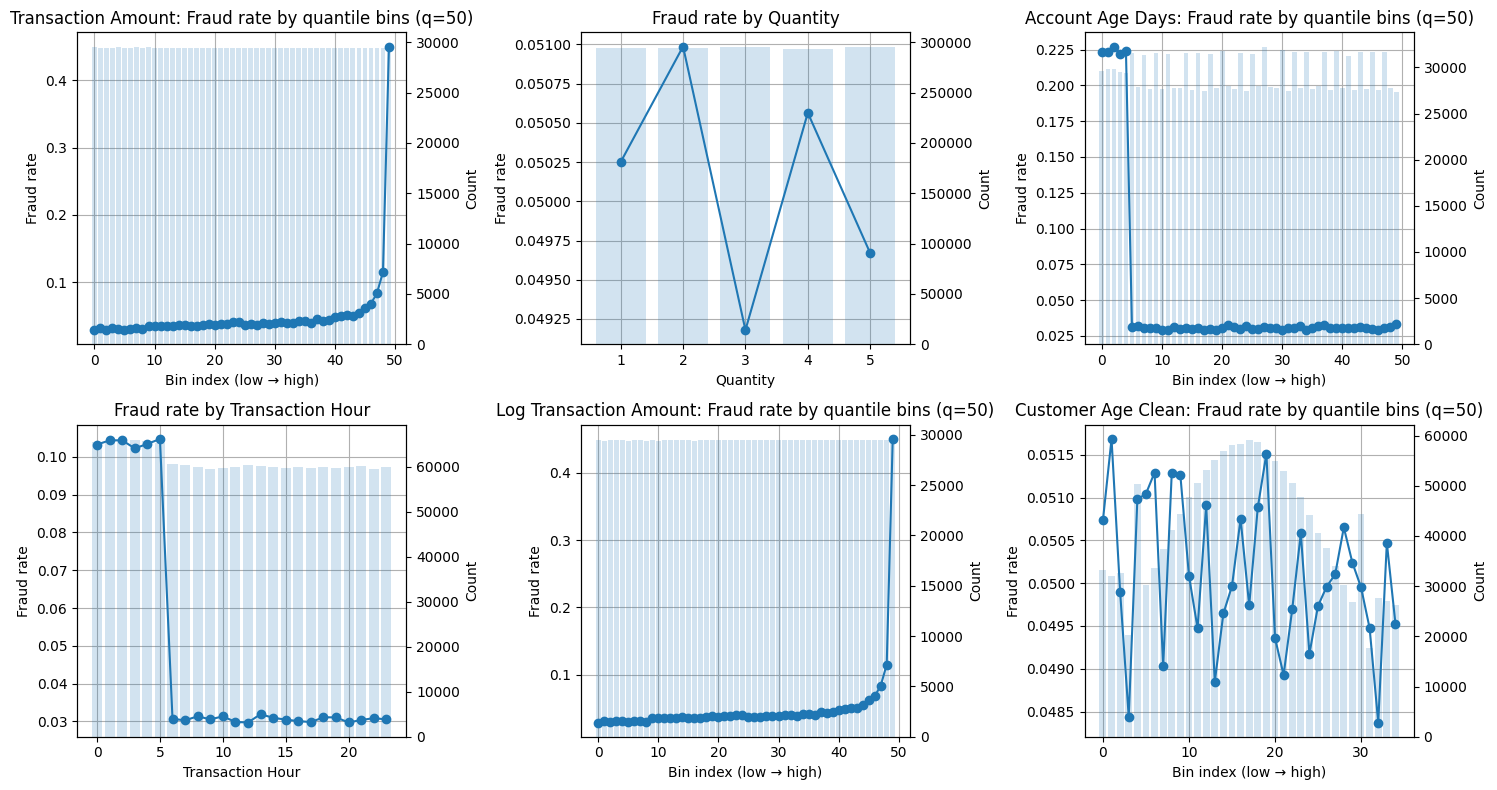

In [43]:
target = 'Is Fraudulent'
Q = 50  # số bins theo quantile (tăng nếu muốn mịn hơn)

n = len(num_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).ravel()

for i, col in enumerate(num_cols):
    tmp = df_model[[col, target]].dropna().copy()
    ax = axes[i]

    nunique = tmp[col].nunique()

    # Vẽ theo giá trị thật nếu unique ít (<=30 unique)
    if nunique <= 30:
        stats = tmp.groupby(col)[target].agg(['mean','size']).reset_index()
        x = stats[col].values
        rate = stats['mean'].values
        cnt = stats['size'].values

        ax.plot(x, rate, marker='o')
        ax.set_xlabel(col)
        ax.set_ylabel('Fraud rate')
        ax.set_title(f'Fraud rate by {col}')

        ax2 = ax.twinx()
        ax2.bar(x, cnt, alpha=0.2)
        ax2.set_ylabel('Count')

    else:
        # Nếu unique > 30 giá trị thì bin theo quantile để biểu đồ mượt hơn
        tmp['bin'] = pd.qcut(tmp[col], q=Q, duplicates='drop')
        stats = tmp.groupby('bin')[target].agg(['mean','size'])
        rate = stats['mean'].values
        cnt = stats['size'].values

        ax.plot(range(len(rate)), rate, marker='o')
        ax.set_title(f'{col}: Fraud rate by quantile bins (q={Q})')
        ax.set_ylabel('Fraud rate')
        ax.set_xlabel('Bin index (low → high)')

        ax2 = ax.twinx()
        ax2.bar(range(len(cnt)), cnt, alpha=0.2)
        ax2.set_ylabel('Count')

    ax.grid(True)

# Tắt các ô thừa
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

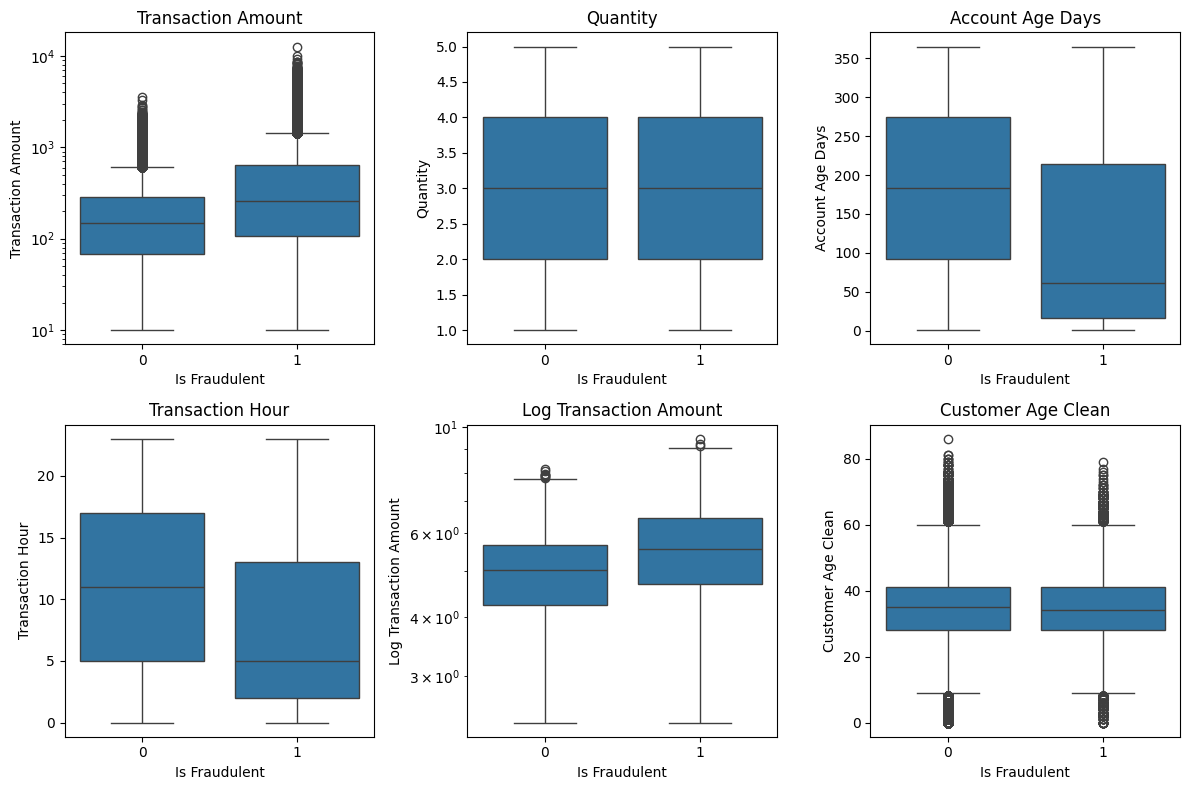

In [44]:
#Vẽ boxplot
cols_to_plot = [
    'Transaction Amount',
 'Quantity',
 'Account Age Days',
 'Transaction Hour',
 'Log Transaction Amount',
 'Customer Age Clean'
]

fig, axes = plt.subplots(2, 3, figsize=(12,8))
axes = axes.ravel()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(data=df_model, x='Is Fraudulent', y=col, ax=axes[i])
    if 'Transaction Amount' in col:
        axes[i].set_yscale('log')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


In [45]:
hour_col = 'Transaction Hour'
target = 'Is Fraudulent'

# Tính fraud rate và count theo từng giờ
hour_stats = (
    df_model.groupby(hour_col)[target]
    .agg(['mean', 'size'])
    .rename(columns={'mean': 'fraud_rate', 'size': 'count'})
    .sort_index()
)


print(hour_stats)
for h, row in hour_stats.iterrows():
    print(f'Hour {h:02d}: Fraud rate = {row['fraud_rate']*100:.2f}% | Count = {int(row['count'])}')


                  fraud_rate  count
Transaction Hour                   
0                   0.103212  65438
1                   0.104307  65317
2                   0.104334  65693
3                   0.102191  66043
4                   0.103376  65721
5                   0.104671  65252
6                   0.030688  60577
7                   0.030314  60501
8                   0.031368  59901
9                   0.030573  59628
10                  0.031342  59792
11                  0.029893  60015
12                  0.029721  60328
13                  0.031934  60124
14                  0.030967  59934
15                  0.030498  59775
16                  0.030100  59868
17                  0.029845  59741
18                  0.031111  59946
19                  0.031081  59682
20                  0.029747  60006
21                  0.030393  60277
22                  0.030877  59430
23                  0.030552  59963
Hour 00: Fraud rate = 10.32% | Count = 65438
Hour 01: Fraud rate

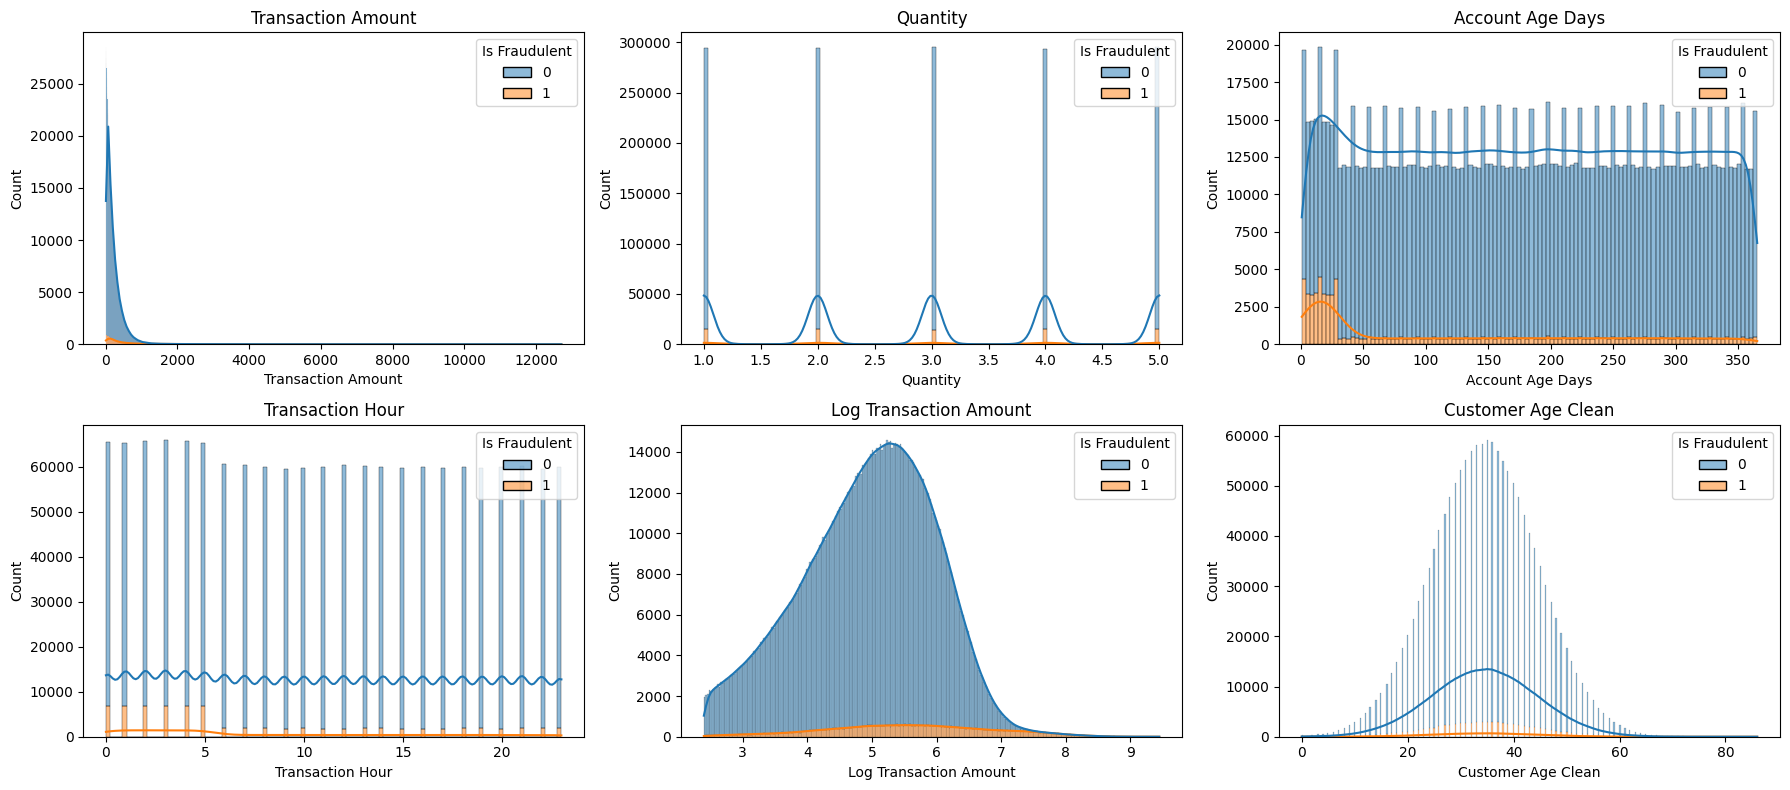

In [46]:
#Visualization các cột features dạng numeric

fig, axes = plt.subplots(2,3,figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df_model, x=col, hue='Is Fraudulent',
        multiple='stack', kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# tắt các ô thừa
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


##Nhận xét:

1) Transaction Amount & Log Transaction Amount

Tín hiệu rất mạnh: fraud rate tăng dần theo amount, đặc biệt tăng vọt ở các bin cao nhất.

Boxplot cũng cho thấy nhóm fraud (1) có xu hướng amount cao hơn.

2) Account Age Days
Fraud rate cao ở nhóm account rất mới (những bin đầu), sau đó rơi xuống và khá phẳng.

=> tài khoản mới tạo dễ gian lận.


3) Transaction Hour

Fraud rate cao rõ rệt ở khoảng 0–5h, rồi giảm mạnh và ổn định.

4) Quantity (1–5)

Fraud rate theo Quantity dao động nhẹ, không có xu hướng rõ.

Boxplot cũng gần như giống nhau.

⇒ Biến này không tác động nhiều đến Fraud

5) Customer Age Clean

Fraud rate  không thấy xu hướng rõ.

Boxplot giữa fraud/non-fraud khá giống nhau.

⇒ Biến này không tác động nhiều đến Fraud

#V/ TRAINING MÔ HÌNH

##1) Chia tập dữ liệu


In [21]:
y=df_model[target]

In [22]:
size = int(len(X) * 0.8)
X_train,X_test = X.iloc[0:size], X.iloc[size:len(X)]
y_train,y_test=y.iloc[0:size],y.iloc[size:len(y)]

#2)Preprocesing dữ liệu

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [24]:
#Tạo pipeline cho feature thuộc cat_cols, chuẩn hoá dữ liệu cho mô hình dạng cây

Preprocessor=ColumnTransformer(transformers=[
    ('num', 'passthrough', num_cols),
    ('cat2','passthrough',cat2_cols),
     ('cat',OneHotEncoder(handle_unknown='ignore') ,cat_cols)
])

##2) Lấy ra 1 vài dòng dữ liệu để làm mẫu train trên tập này

In [25]:
##lấy 70000 của train để tune (70.000 dòng). Lấy phần cuối dữ liệu của train để training
sample_size =70_000
sample_X = X_train.tail(sample_size)
sample_y = y_train.tail(sample_size)


In [26]:
#Kiểm tra tỷ lệ Fraud có tương ứng với toàn tapo65 dữ liệu
print('Sample size:', len(sample_y))
print('Fraud count:', (sample_y == 1).sum())
print('Non-fraud count:', (sample_y == 0).sum())
print('Fraud rate (%):', 100 * (sample_y == 1).mean())

Sample size: 70000
Fraud count: 3621
Non-fraud count: 66379
Fraud rate (%): 5.172857142857143


##3)Training mô hình trên tập mẫu 70.000

##A)MÔ HÌNH DECISION TREE, RF

In [28]:
# Oversampling (Random)
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=0)
# Oversampling (SMOKE - Nội suy thêm dữ liệu)
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=0)
# Oversampling (ADASYN - Dựa và các giá trị khó phân loại để tạo thêm dữ liệu)
from imblearn.over_sampling import ADASYN
ad = ADASYN(random_state=0)
# Combine (kết hợp Under Sampling + Oversampling SMOTETomek)
from imblearn.combine import SMOTETomek
smt = SMOTETomek(random_state=0)
# Combine (kết hợp Under Sampling + Oversampling SMOKEENN)
from imblearn.combine import SMOTEENN
smn = SMOTEENN(random_state=0)
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=0)



In [29]:
# 5) Khởi mô hình và tunning mô hình
import time
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, roc_auc_score, accuracy_score, classification_report, confusion_matrix, precision_recall_curve

In [55]:
cv = TimeSeriesSplit(n_splits=3)

param_grid_dt = {
    'clf__criterion': ['gini', 'entropy'],
    'clf__max_depth': [3,4,5,6,7],
    'clf__min_samples_split': [2,5,10],
    'clf__min_samples_leaf': [10,20,50]
}

pipes_tune = {

    'DT_balanced': ImbPipeline([('prep', Preprocessor),
                               ('clf', DecisionTreeClassifier(random_state=99, class_weight='balanced'))]),

    'DT_Under': ImbPipeline([('prep', Preprocessor),
                             ('sampler', RandomUnderSampler(random_state=99)),
                             ('clf', DecisionTreeClassifier(random_state=99))])

}


best_params_by_method = {}
best_scores = {}
tune_summary = []

for name, pipe in pipes_tune.items():
    print(f'\n=== Tuning {name} ===')
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid_dt,
        scoring='average_precision',
        cv=cv,
        n_jobs=-1
    )
    start = time.time()
    gs.fit(sample_X, sample_y)
    t = time.time() - start

    best_params_by_method[name] = gs.best_params_
    tune_summary.append({
        'method': name,
        'cv_pr_auc': gs.best_score_,
        'time': t,
        'best_params': gs.best_params_
    })

tune_df = pd.DataFrame(tune_summary)
display(tune_df)


=== Tuning DT_balanced ===

=== Tuning DT_Under ===


,method,cv_pr_auc,time,best_params
0,DT_balanced,0.322484,75.818835,"{'clf__criterion': 'entropy', 'clf__max_depth': 4, 'clf__min_samples_leaf': 50, 'clf__min_samples_split': 2}"
1,DT_Under,0.283377,35.561548,"{'clf__criterion': 'gini', 'clf__max_depth': 4, 'clf__min_samples_leaf': 50, 'clf__min_samples_split': 2}"


In [56]:
#1) Mô hình DT mặc định
dt_default = Pipeline(steps=[
    ('prep', Preprocessor),
    ('clf', DecisionTreeClassifier(random_state=99))
])

# 2) Model DT with balanced
dt_balanced = Pipeline(steps=[
    ('prep', Preprocessor),
    ('clf', DecisionTreeClassifier(
        random_state=99,
        class_weight='balanced',
        criterion='entropy',
        max_depth=4,
        min_samples_leaf=50,
        min_samples_split=2
    ))
])

# 5) Model with RandomUnderSampler
dt_RandomUnderSampler = ImbPipeline(steps=[
    ('prep', Preprocessor),
    ('sampler', RandomUnderSampler(random_state=99)),
    ('clf', DecisionTreeClassifier(
        random_state=99,
        class_weight=None,
        criterion='gini',
        max_depth=4,
        min_samples_leaf=50,
        min_samples_split=2
    ))
])


In [57]:
#List of model
model_list_dt={'DecisionTree_Default':dt_default,
            'DecisionTree_Balanced':dt_balanced,
            'DecisionTree_RandomUnderSampler':dt_RandomUnderSampler
            }

In [58]:
#Khởi tạo list data để ghi nhận kết quả training của mô hình
model_results_dt = []

Running model DecisionTree_Default


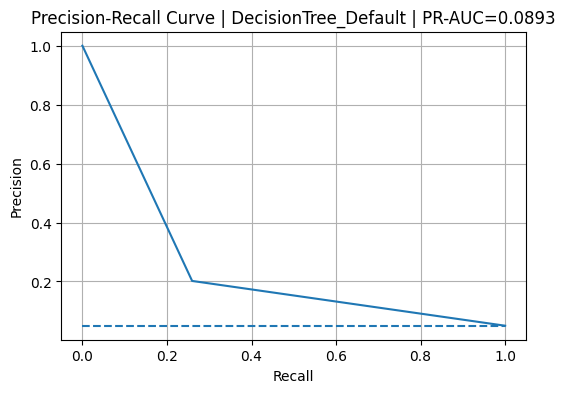

cn_matrix:
 [[264829  15075]
 [ 10875   3812]]
Running model DecisionTree_Balanced


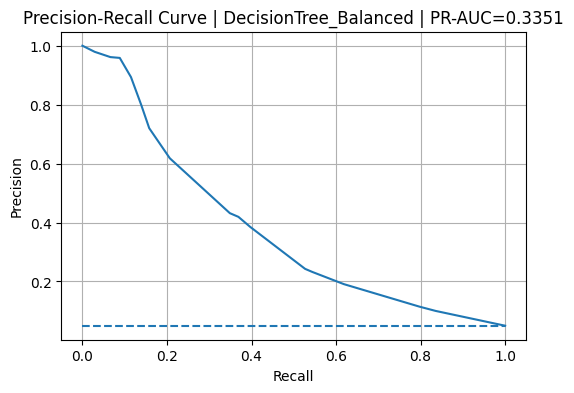

cn_matrix:
 [[241429  38475]
 [  5604   9083]]
Running model DecisionTree_RandomUnderSampler


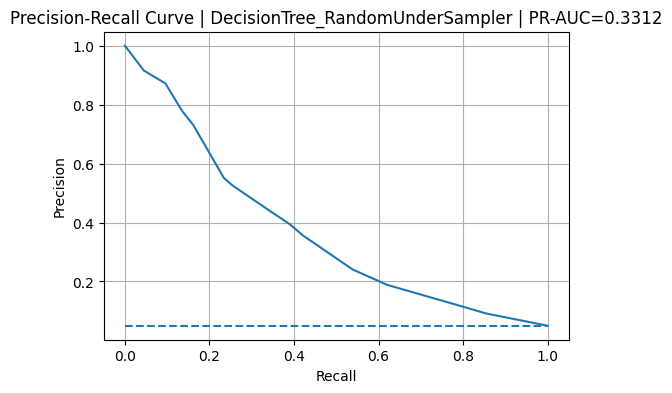

cn_matrix:
 [[240727  39177]
 [  5580   9107]]


In [59]:
# Training và tính toán thông số đáng giá mô hình
for name_md, model in model_list_dt.items():
  print(f'Running model {name_md}')

  start_time = time.time()
  model.fit(X_train, y_train)
  take_time = (time.time() - start_time)

  from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

  proba=model.predict_proba(X_test)[:, 1]
  y_pred = model.predict(X_test)

  # Tính toán các chỉ số
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  PR_AUC_score=average_precision_score(y_test, proba)

  # PR curve
  pr_curve_prec, pr_curve_rec, threholds= precision_recall_curve(y_test, proba)

  plt.figure(figsize=(6,4))
  plt.plot(pr_curve_rec, pr_curve_prec)

  base = y_test.mean()
  plt.hlines(base, 0, 1, linestyles='--')

  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.title(f'Precision-Recall Curve | {name_md} | PR-AUC={ PR_AUC_score:.4f}')
  plt.grid(True)
  plt.show()


  print('cn_matrix:\n', confusion_matrix(y_test, y_pred))
  result = {
            'model': name_md,
            'PR-AUC': PR_AUC_score,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'take_time': take_time}

  model_results_dt.append(result)

In [60]:
#Đánh giá mô hình
dt_model = pd.DataFrame(model_results_dt)
dt_model

,model,PR-AUC,accuracy,precision,recall,f1_score,take_time
0,DecisionTree_Default,0.089301,0.911912,0.201832,0.259549,0.227080,51.667652
1,DecisionTree_Balanced,0.335050,0.850372,0.190988,0.618438,0.291847,16.987156
2,DecisionTree_RandomUnderSampler,0.331208,0.848071,0.188613,0.620072,0.289244,3.435012


#Nhận xét:
1) Default (không xử lý mất cân bằng) cho chất lượng phát hiện fraud kém

PR-AUC = 0.0893 → rất thấp

Confusion matrix: TP=3,812, FN=10,875, FP=15,075, TN=264,829

Precision = 0.2, Recall = 0.26

=>Mô hình bỏ sót Fraud nhiều

2) Balanced cải thiện mạnh khả năng nhận diện fraud (đổi lại báo nhầm tăng)

PR-AUC = 0.3351 (tăng rất mạnh so với 0.0893)

Confusion matrix: TP=9,083, FN=5,604, FP=38,475, TN=244,129

Precision = 0.19, Recall = 0.62

=> Mô hginh2 bắt được nhiều Frau nhưng cũng báo nhầm khá nhiều

3) RandomUnderSampler cho hiệu quả gần như Balanced

PR-AUC = 0.3312 (gần bằng Balanced)

Confusion matrix: TP=9,107, FN=5,580, FP=39,177, TN=240,727

Precision = 0.19, Recall =0.62

KẾT LUẬN CHO MÔ HÌNH DT: Balanced và UnderSampler là 2 lựa chọn tối ưu hơn. Nếu ưu tiên về tời gian chạy thì UnderSampler là lựa chọn hợp lý

In [61]:
param_grid_rf={'clf__n_estimators': list(range(300, 401, 50)),
              'clf__max_depth': [5, 10, 20],
            }

pipes_tune = {

    'RF_balanced': ImbPipeline([('prep', Preprocessor),
                               ('clf', RandomForestClassifier(random_state=99, class_weight='balanced_subsample'))]),


    'RF_Under': ImbPipeline([('prep', Preprocessor),
                             ('sampler', RandomUnderSampler(random_state=99)),
                             ('clf', RandomForestClassifier(random_state=99))]),

}

best_params_by_method = {}
best_scores = {}
tune_summary = []

for name, pipe in pipes_tune.items():
    print(f'\n=== Tuning {name} ===')
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid_rf,
        scoring='average_precision',
        cv=cv,
        n_jobs=-1
    )
    start = time.time()
    gs.fit(sample_X, sample_y)
    t = time.time() - start


    best_params_by_method[name] = gs.best_params_
    tune_summary.append({
        'method': name,
        'cv_pr_auc': gs.best_score_,
        'time': t,
        'best_params': gs.best_params_
    })

tune_rf = pd.DataFrame(tune_summary)
display(tune_rf)


=== Tuning RF_balanced ===

=== Tuning RF_Under ===


,method,cv_pr_auc,time,best_params
0,RF_balanced,0.360386,321.560200,"{'clf__max_depth': 5, 'clf__n_estimators': 300}"
1,RF_Under,0.343545,45.105014,"{'clf__max_depth': 5, 'clf__n_estimators': 400}"


In [62]:
#1)Mô hình RF mặc định
rf_default = Pipeline(steps=[
    ('prep', Preprocessor),
    ('clf', RandomForestClassifier(random_state=99))
])

# 1) Model RF with balanced
rf_balanced = Pipeline(steps=[
    ('prep', Preprocessor),
    ('clf', RandomForestClassifier(
        random_state=99,
        class_weight='balanced_subsample',
        max_depth=5,
        n_estimators=300
    ))
])


# 2) Model with RandomUnderSampler
rf_RandomUnderSampler = ImbPipeline(steps=[
    ('prep', Preprocessor),
    ('sampler', RandomUnderSampler(random_state=99)),
    ('clf',  RandomForestClassifier(
        random_state=99,
        class_weight=None,
        max_depth=5,
        n_estimators=400
    ))
])



In [63]:
#List of model
model_list_rf={'RF_Default':rf_default,
            'RF_Balanced':rf_balanced,
            'RF_RandomUnderSampler':rf_RandomUnderSampler
            }

In [64]:
#Khởi tạo list data để ghi nhận kết quả training của mô hình
model_results_rf = []

Running model RF_Default


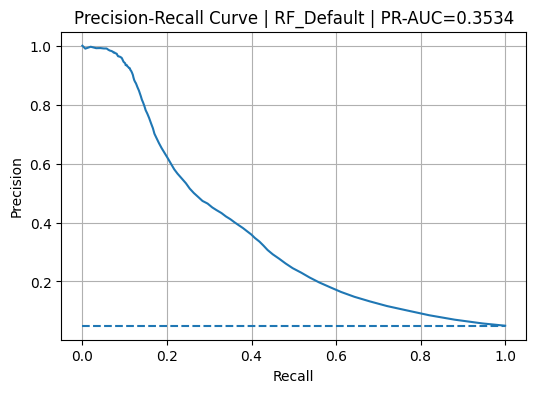

cn_matrix:
 [[279289    615]
 [ 12490   2197]]
Running model RF_Balanced


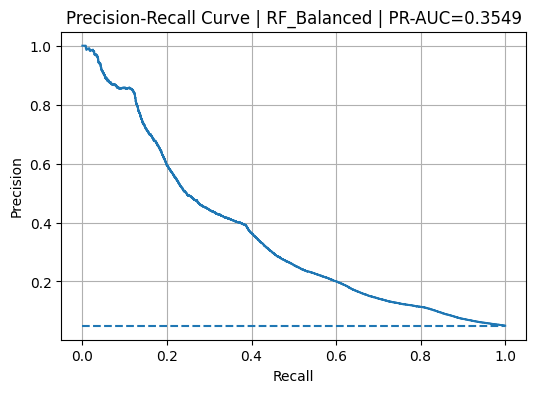

cn_matrix:
 [[239638  40266]
 [  5522   9165]]
Running model RF_RandomUnderSampler


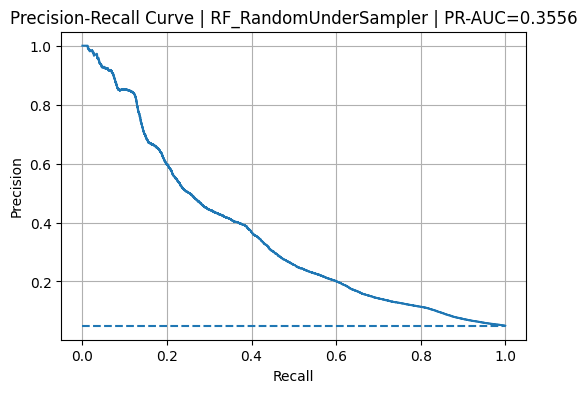

cn_matrix:
 [[239638  40266]
 [  5525   9162]]


In [65]:
# Training và tính toán thông số đáng giá mô hình
for name_md, model_rf in model_list_rf.items():
  print(f'Running model {name_md}')

  start_time = time.time()
  model_rf.fit(X_train, y_train)
  take_time = (time.time() - start_time)

  from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

  proba=model_rf.predict_proba(X_test)[:, 1]
  y_pred = model_rf.predict(X_test)

  # Tính toán các chỉ số
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  PR_AUC_score=average_precision_score(y_test, proba)

   # ===== PR curve =====
  pr_curve_prec, pr_curve_rec, threholds= precision_recall_curve(y_test, proba)

  plt.figure(figsize=(6,4))
  plt.plot(pr_curve_rec, pr_curve_prec)

  base = y_test.mean()
  plt.hlines(base, 0, 1, linestyles='--')

  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.title(f'Precision-Recall Curve | {name_md} | PR-AUC={ PR_AUC_score:.4f}')
  plt.grid(True)
  plt.show()

  print('cn_matrix:\n', confusion_matrix(y_test, y_pred))
  result = {
            'model': name_md,
            'PR-AUC': PR_AUC_score,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'take_time': take_time}

  model_results_rf.append(result)

In [66]:
#Đánh giá mô hình
rf_model = pd.DataFrame(model_results_rf)
rf_model

,model,PR-AUC,accuracy,precision,recall,f1_score,take_time
0,RF_Default,0.353407,0.955515,0.781294,0.149588,0.251100,613.506793
1,RF_Balanced,0.354945,0.844571,0.185410,0.624021,0.285879,728.376173
2,RF_RandomUnderSampler,0.355615,0.844561,0.185361,0.623817,0.285799,48.372198


#Nhận xét
1) RF_Default

PR-AUC = 0.3534

Confusion matrix: TP=2,197, FN=12,490, FP=615, TN=279,289

Precision = 0.78 (rất cao)

Recall = 0.14 (rất thấp) → chỉ bắt được ~15% fraud

=> Dự đoán đúng frau cao nhưng tỷ lệt bắt fraud thật rất thấp, bỏ sót fraud rất nhiều

2) RF_Balanced cải thiện mạnh khả năng phát hiện fraud

PR-AUC = 0.3549

Confusion matrix: TP=9,165, FN=5,522, FP=40,266, TN=239,638

Precision = 0.18

Recall = 0.62

=> Mô hình nhạy với fraud hơn rõ rệt: bắt được 62% fraud (TP tăng mạnh, FN giảm nhiều). Tuy nhiên, báo nhầm tăng (FP tăng) nên precision giảm xuống 0.18

3)RF_RandomUnderSampler

PR-AUC = 0.35 (cao nhất, nhỉnh hơn chút)

Confusion matrix gần như Balanced: TP=9,162, FN=5,525, FP=40,266, TN=239,638

Accuracy = 0.84

Precision = 0.18, Recall = 0.62

=>Hiệu quả gần như RF_Balanced nhưng chạy nhanh hơn

# MÔ HÌNH LR

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [68]:
#preprocessing dữ liệu mô hình LR

Preprocessor_lr=ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat2_cols', 'passthrough', cat2_cols),
    ( 'cat',OneHotEncoder(handle_unknown='ignore') ,cat_cols)
])

In [69]:
cv = TimeSeriesSplit(n_splits=3)

param_grid_lr = {
    'clf__C': [0.01, 0.1, 1.0, 10.0],
    'clf__penalty': ['l1', 'l2'],
    'clf__class_weight': [None, 'balanced']
}

pipes_tune = {

    'LR_no_resample': ImbPipeline([('prep', Preprocessor_lr),
                               ('clf', LogisticRegression(random_state=99,solver='saga',max_iter=3000))]),


    'LR_Under': ImbPipeline([('prep', Preprocessor_lr),
                             ('sampler', RandomUnderSampler(random_state=99)),
                             ('clf', LogisticRegression(random_state=99,solver='saga',max_iter=3000))])

}

best_params_by_method = {}
best_scores = {}
tune_summary = []

for name, pipe in pipes_tune.items():
    print(f'\n=== Tuning {name} ===')
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid_lr,
        scoring='average_precision',
        cv=cv,
        n_jobs=-1
    )
    start = time.time()
    gs.fit(sample_X, sample_y)
    t = time.time() - start

    best_params_by_method[name] = gs.best_params_
    tune_summary.append({
        'method': name,
        'cv_pr_auc': gs.best_score_,
        'time': t,
        'best_params': gs.best_params_
    })

tune_lr = pd.DataFrame(tune_summary)
display(tune_lr)




=== Tuning LR_no_resample ===



=== Tuning LR_Under ===


,method,cv_pr_auc,time,best_params
0,LR_no_resample,0.317029,451.629471,"{'clf__C': 0.01, 'clf__class_weight': None, 'clf__penalty': 'l1'}"
1,LR_Under,0.317540,21.034024,"{'clf__C': 0.01, 'clf__class_weight': None, 'clf__penalty': 'l1'}"


In [70]:

lr_default=Pipeline(steps=[
    ('prep', Preprocessor_lr),
    ('clf', LogisticRegression(
        random_state=99,
        max_iter=5000)
)])

lr_no_resample=Pipeline(steps=[
    ('prep', Preprocessor_lr),
    ('clf', LogisticRegression(
        random_state=99,solver='saga',
        max_iter=5000,
        class_weight=None,
        C=0.01,
        penalty='l1',
        )
)])


lr_random_under=ImbPipeline(steps=[
    ('prep', Preprocessor_lr),
    ('sampler', RandomUnderSampler(random_state=99)),
    ('clf', LogisticRegression(
        random_state=99,solver='saga',
        max_iter=5000,
        class_weight=None,
        C=0.01,
        penalty='l1',
        )
)])




In [71]:
model_list_lr = {
    'logisticRegression': lr_default,
    'LR_no_sample': lr_no_resample,
    'LR_RandomUnderSampler': lr_random_under,

}

In [72]:
# Khởi tạo list data để ghi nhận kết quả training của mô hình
model_results_lr = []

Running model logisticRegression


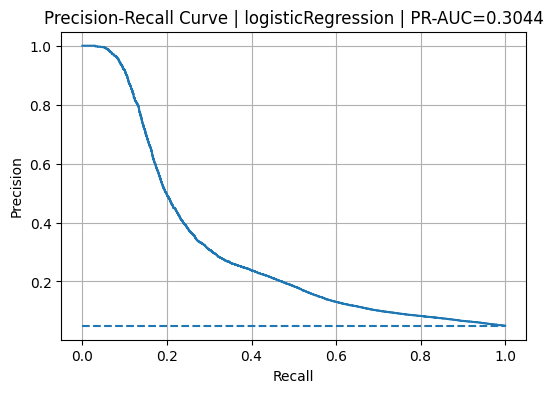

cn_matrix:
 [[279483    421]
 [ 12855   1832]]
Running model LR_no_sample


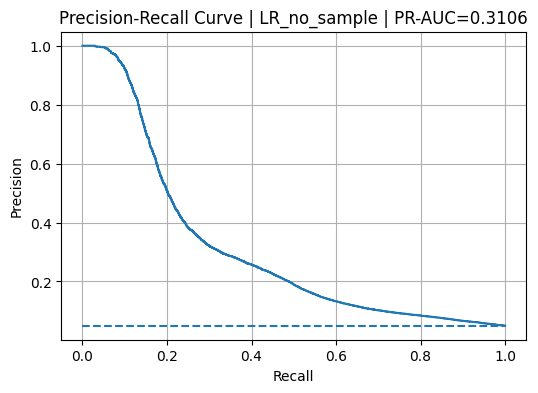

cn_matrix:
 [[279566    338]
 [ 12899   1788]]
Running model LR_RandomUnderSampler


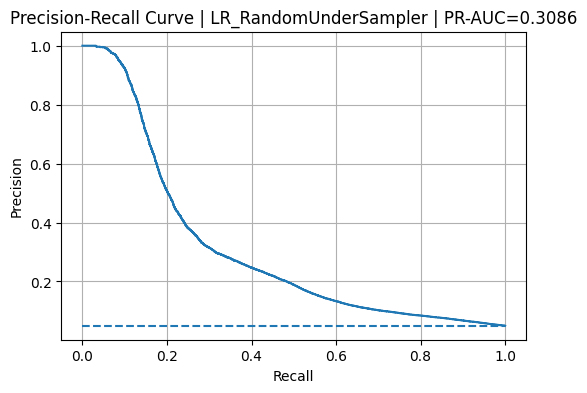

cn_matrix:
 [[204656  75248]
 [  5063   9624]]


In [73]:
# Khời tạo vòng lặp training và ghi nhận kết quả mô hình

for name_md, model_lr in model_list_lr.items():
  print(f'Running model {name_md}')

  start_time = time.time()
  model_lr.fit(X_train, y_train)
  take_time = (time.time() - start_time)


  from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

  # Dự đoán y
  proba=model_lr.predict_proba(X_test)[:, 1]
  y_pred = model_lr.predict(X_test)

  # Tính toán các chỉ số

  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  PR_AUC_score=average_precision_score(y_test, proba)

   # ===== PR curve =====
  pr_curve_prec, pr_curve_rec, threholds= precision_recall_curve(y_test, proba)

  plt.figure(figsize=(6,4))
  plt.plot(pr_curve_rec, pr_curve_prec)

  base = y_test.mean()
  plt.hlines(base, 0, 1, linestyles='--')

  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.title(f'Precision-Recall Curve | {name_md} | PR-AUC={ PR_AUC_score:.4f}')
  plt.grid(True)
  plt.show()

  print('cn_matrix:\n', confusion_matrix(y_test, y_pred))
  result = {
            'model': name_md,
            'PR-AUC': PR_AUC_score,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'take_time': take_time}

  model_results_lr.append(result)

In [74]:
#Đánh giá mô hình
lr_model = pd.DataFrame(model_results_lr)
lr_model

,model,PR-AUC,accuracy,precision,recall,f1_score,take_time
0,logisticRegression,0.304428,0.954934,0.813138,0.124736,0.216293,6.299096
1,LR_no_sample,0.310618,0.955067,0.841016,0.121740,0.212693,23.278052
2,LR_RandomUnderSampler,0.308648,0.727381,0.113394,0.655273,0.193333,4.015619


# Nhận xét

1) LR mặc định/LR_no_sample:

hai mô hình này khá giống nhau, LR_no_sample có thêm 1 vài siêu tham số

logisticRegression

PR-AUC = 0.3, Accuracy = 0.95

Precision = 0.81 (rất cao)

Recall = 0.12 (rất thấp)

Confusion matrix: TN=279,483  FP=421  FN=12,855  TP=1,832

LR_no_sample

PR-AUC = 0.31 (cao nhất trong 3 LR)

Accuracy = 0.95

Precision = 0.84 (cao)

Recall = 0.12 (rất thấp)

Confusion matrix: TN=279,566 , FP=388 ,  FN=12,899 , TP=1,788

2) LR + RandomUnderSampler: recall tăng rất mạnh nhưng precision giảm sâu

LR_RandomUnderSampler

PR-AUC = 0.3086 (gần tương đương hai mô hình trên)

Accuracy = 0.72 (giảm mạnh)

Precision = 0.11 (thấp)

Recall = 0.65 (rất cao)

Confusion matrix: TN=204,656 , FP=75,248 , FN=5,063 , TP=9,624

=>Under-sampling làm mô hình  bắt được fraud tốt (recall 65%), nhưng báo nhầm cực nhiều (FP tăng mạnh), kéo precision xuống 11%.

# MÔ HÌNH XGB

In [33]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 6.3 MB/s eta 0:00:16
    --------------------------------------- 2.4/101.7 MB 6.7 MB/s eta 0:00:15
   - -------------------------------------- 3.9/101.7 MB 6.7 MB/s eta 0:00:15
   -- ------------------------------------- 5.5/101.7 MB 7.0 MB/s eta 0:00:14
   -- ------------------------------------- 7.1/101.7 MB 7.0 MB/s eta 0:00:14
   --- ------------------------------------ 9.2/101.7 MB 7.4 MB/s eta 0:00:13
   ---- ----------------------------------- 11.0/101.7 MB 7.6 MB/s eta 0:00:12
   ----- ---------------------------------- 12.8/101.7 MB 7.7 MB/s eta 0:00:12
   ----- ---------------------------------- 14.4/101.7 MB 7.9 MB/s eta 0:00:12
   ------ --------------------------------- 16.5/101.7 MB 8.0 MB/s eta 0:00:11
   ------- -------------------------------- 18.1/101.7 MB 7.9 MB/s eta 0:00:11
   ------- -------------------------------- 19.9/101.7 MB 8.0 MB/s


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
#Tunning mô hình XGBoost
from xgboost import XGBClassifier


In [35]:
# scale_pos_weight ~ (neg / pos) tính trên tập train sample_y_train
pos = (y_train==1).sum()
neg = (y_train==0).sum()
spw = neg/max(pos,1)

In [36]:
# GridSearchCV (tune)
param_grid_xgb = {
    'clf__n_estimators': [200, 400],
    'clf__max_depth': [3, 5],
    'clf__learning_rate': [0.05, 0.1],
    'clf__subsample': [0.8,1.0],
    'clf__colsample_bytree': [0.8, 1.0],
    'clf__min_child_weight': [1, 5, 10],

}

cv = TimeSeriesSplit(n_splits=3)

pipes_tune = {

    'XGB_weighted': ImbPipeline([('prep', Preprocessor),
                                ('clf', XGBClassifier(random_state=99, objective='binary:logistic',eval_metric='aucpr',scale_pos_weight=spw,tree_method='hist',n_jobs=-1))]),


    'XGB_Under': ImbPipeline([('prep', Preprocessor),
                            ('sampler', RandomUnderSampler(random_state=99)),
                            ('clf', XGBClassifier(random_state=99,eval_metric='aucpr',tree_method='hist',n_jobs=-1))])
}

best_params_by_method = {}
best_scores = {}
tune_summary = []

for name, pipe in pipes_tune.items():
    print(f'\n=== Tuning {name} ===')
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid_xgb,
        scoring='average_precision',
        cv=cv,
        n_jobs=1
    )
    start = time.time()
    gs.fit(sample_X, sample_y)
    t = time.time() - start

    best_params_by_method[name] = gs.best_params_
    tune_summary.append({
        'method': name,
        'cv_pr_auc': gs.best_score_,
        'time': t,
        'best_params': gs.best_params_
    })

tune_xgb = pd.DataFrame(tune_summary)
display(tune_xgb)





=== Tuning XGB_weighted ===

=== Tuning XGB_Under ===


,method,cv_pr_auc,time,best_params
0,XGB_weighted,0.378132,546.264308,"{'clf__colsample_bytree': 1.0, 'clf__learning_..."
1,XGB_Under,0.353716,210.740800,"{'clf__colsample_bytree': 1.0, 'clf__learning_..."


In [38]:

# 1) XGBoost mặc định (không resample)
xgb_default = Pipeline(steps=[
    ('prep', Preprocessor),
    ('clf', XGBClassifier(
        random_state=99,
        eval_metric='logloss',
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=1.0,
        colsample_bytree=1.0,
        tree_method='hist',
        n_jobs=-1
    ))
])

# 2) XGBoost không resample nhưng xử lý mất cân bằng bằng scale_pos_weight

xgb_weighted = Pipeline(steps=[
    ('prep', Preprocessor),
    ('clf', XGBClassifier(
        random_state=99,
        eval_metric='aucpr',
        colsample_bytree=1,
        learning_rate=0.05,
        max_depth=3,
        min_child_weight= 10,
        n_estimators=200,
        subsample=0.8,
        scale_pos_weight=spw,
        tree_method='hist',
        n_jobs=-1
    ))
])


# 3) XGBoost + RandomUnderSampler
xgb_under = ImbPipeline(steps=[
    ('prep', Preprocessor),
    ('sampler', RandomUnderSampler(random_state=99)),
    ('clf', XGBClassifier(
        random_state=99,
        eval_metric='aucpr',
        colsample_bytree=1,
        learning_rate=0.05,
        max_depth=3,
        min_child_weight= 1,
        n_estimators=200,
        subsample=1,
        tree_method='hist',
        n_jobs=-1
    ))
])

In [39]:
model_list_xg = {
    'xgb_default': xgb_default,
    'xgb_weighted': xgb_weighted,
    'xgb_under': xgb_under
}

In [40]:
# Khởi tạo list data để ghi nhận kết quả training của mô hình
model_results_xg = []

Running model xgb_default


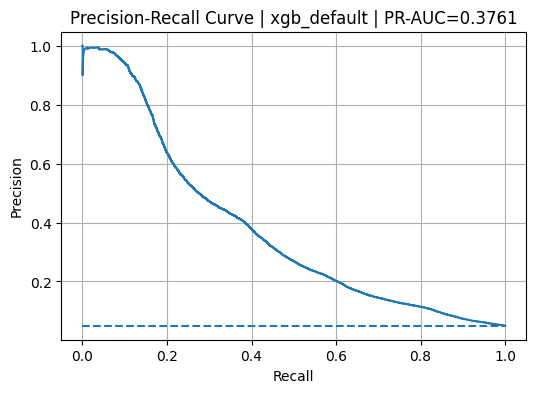

cn_matrix:
 [[279361    543]
 [ 12448   2239]]
Running model xgb_weighted


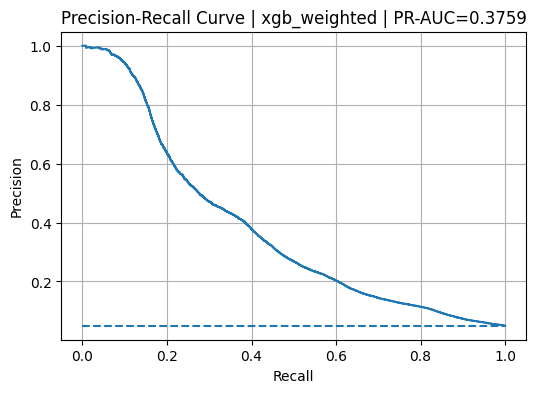

cn_matrix:
 [[217238  62666]
 [  4330  10357]]
Running model xgb_under


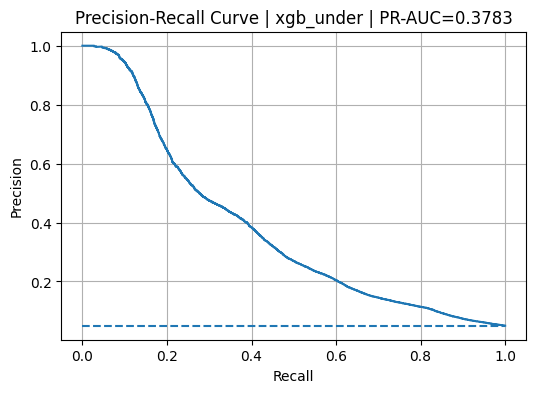

cn_matrix:
 [[222044  57860]
 [  4577  10110]]


In [41]:
# Khời tạo vòng lặp training và ghi nhận kết quả mô hình

for name_md, model_xg in model_list_xg.items():
  print(f'Running model {name_md}')

  start_time = time.time()
  model_xg.fit(X_train, y_train)
  take_time = (time.time() - start_time)

  from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
  # Xử lý chuyển đổi dữ liệu X test

  # Dự đoán y
  proba=model_xg.predict_proba(X_test)[:, 1]
  y_pred = model_xg.predict(X_test)

  # Tính toán các chỉ số
   # Tính toán các chỉ số
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  PR_AUC_score=average_precision_score(y_test, proba)

   # ===== PR curve (mỗi model 1 hình) =====
  pr_curve_prec, pr_curve_rec, threholds= precision_recall_curve(y_test, proba)

  plt.figure(figsize=(6,4))
  plt.plot(pr_curve_rec, pr_curve_prec)

  base = y_test.mean()
  plt.hlines(base, 0, 1, linestyles='--')

  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.title(f'Precision-Recall Curve | {name_md} | PR-AUC={ PR_AUC_score:.4f}')
  plt.grid(True)
  plt.show()

  print('cn_matrix:\n', confusion_matrix(y_test, y_pred))
  result = {
            'model': name_md,
            'PR-AUC': PR_AUC_score,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'take_time': take_time}

  model_results_xg.append(result)

In [ ]:
#Đánh giá mô hình
xg_model = pd.DataFrame(model_results_xg)
xg_model

,model,PR-AUC,accuracy,precision,recall,f1_score,take_time
0,xgb_default,0.376140,0.955902,0.804817,0.152448,0.256340,15.630611
1,xgb_weighted,0.375882,0.774946,0.143100,0.704501,0.237881,16.274364
2,xgb_under,0.378284,0.788055,0.148742,0.688364,0.244625,2.788809


#Nhận xét:
1) xgb_default:

Confusion matrix: TN=279,361 , FP=543 , FN=12,448 , TP=2,239

Precision = 0.80

Recall = 0.15

=>  XGB default khá giống RF/LR default : FP thấp nên precision cao, nhưng bỏ sót phần lớn fraud.

2) xgb_under và xgb_weighted: recall tăng mạnh, đổi lại FP tăng, precision giảm

xgb_under: TN=222,044 , FP=57,860 , FN=4,577 , TP=10,110

Precision = 0.14

Recall = 0.68

xgb_weighted: TN=217,945 , FP=61,959 , FN=4,340 , TP=10,347

Precision = 0.14

Recall = 0.7

=>Hai cách xử lý mất cân bằng (under/weighted) giúp XGBoost bắt được 68–70% fraud, giảm FN mạnh so với default. Tuy nhiên FP tăng lên đáng kể nên precision giảm (khoảng 14–15%). Under-sampling có thời gian chạy nhanh và chỉ số PR-AUC vẫn giữ ở mức cao


# KẾT QUẢ CÁC MODEL

In [ ]:
dt_model

,model,PR-AUC,accuracy,precision,recall,f1_score,take_time
0,DecisionTree_Default,0.089301,0.911912,0.201832,0.259549,0.227080,27.949006
1,DecisionTree_Balanced,0.335050,0.850372,0.190988,0.618438,0.291847,7.264378
2,DecisionTree_RandomUnderSampler,0.331208,0.848071,0.188613,0.620072,0.289244,1.830501


In [ ]:
rf_model

,model,PR-AUC,accuracy,precision,recall,f1_score,take_time
0,RF_Default,0.353407,0.955515,0.781294,0.149588,0.251100,313.002951
1,RF_Balanced,0.354945,0.844571,0.185410,0.624021,0.285879,350.807249
2,RF_RandomUnderSampler,0.355615,0.844561,0.185361,0.623817,0.285799,27.565010


In [ ]:
lr_model

,model,PR-AUC,accuracy,precision,recall,f1_score,take_time
0,logisticRegression,0.304428,0.954934,0.813138,0.124736,0.216293,3.782016
1,LR_no_sample,0.310618,0.955067,0.841016,0.121740,0.212693,18.700334
2,LR_RandomUnderSampler,0.308648,0.727381,0.113394,0.655273,0.193333,2.564761


In [ ]:
xg_model

,model,PR-AUC,accuracy,precision,recall,f1_score,take_time
0,xgb_default,0.376140,0.955902,0.804817,0.152448,0.256340,15.630611
1,xgb_weighted,0.375882,0.774946,0.143100,0.704501,0.237881,16.274364
2,xgb_under,0.378284,0.788055,0.148742,0.688364,0.244625,2.788809


#ĐÁNH GIÁ BIẾN QUAN TRỌNG

## Chọn mô hình tối ưu



In [ ]:
#Lấy model tốt nhất theo PR-AUC từ bảng kết quả
res_df = pd.DataFrame(model_results_dt)
best_name_dt = res_df.sort_values("PR-AUC", ascending=False).iloc[0]["model"]
print("Best model DT:", best_name_dt)
best_model_dt = model_list_dt[best_name_dt]

Best model DT: DecisionTree_Balanced


In [ ]:
res_rf = pd.DataFrame(model_results_rf)
best_name_rf = res_rf.sort_values("PR-AUC", ascending=False).iloc[0]["model"]
print("Best model RF:", best_name_rf)
best_model_rf = model_list_rf[best_name_rf]

Best model RF: RF_RandomUnderSampler


In [ ]:
res_lr = pd.DataFrame(model_results_lr)
best_name_lr = res_lr.sort_values("PR-AUC", ascending=False).iloc[0]["model"]
print("Best model LR:", best_name_lr)
best_model_lr = model_list_lr[best_name_lr]

Best model LR: LR_no_sample


In [ ]:
res_xg = pd.DataFrame(model_results_xg)
best_name_xg = res_xg.sort_values("PR-AUC", ascending=False).iloc[0]["model"]
print("Best model XG:", best_name_xg)
best_model_xg = model_list_xg[best_name_xg]
best_model_xg

Best model XG: xgb_under


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Transaction Amount',
                                                   'Quantity',
                                                   'Account Age Days',
                                                   'Transaction Hour',
                                                   'Log Transaction Amount',
                                                   'Customer Age Clean']),
                                                 ('cat2', 'passthrough',
                                                  ['Age Invalid',
                                                   'Ship_Bill_Match']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Payment Method',
                                                   'Product Category',
                                                   'Device Used',
                                                   'Transaction...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None, min_child_weight=1,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

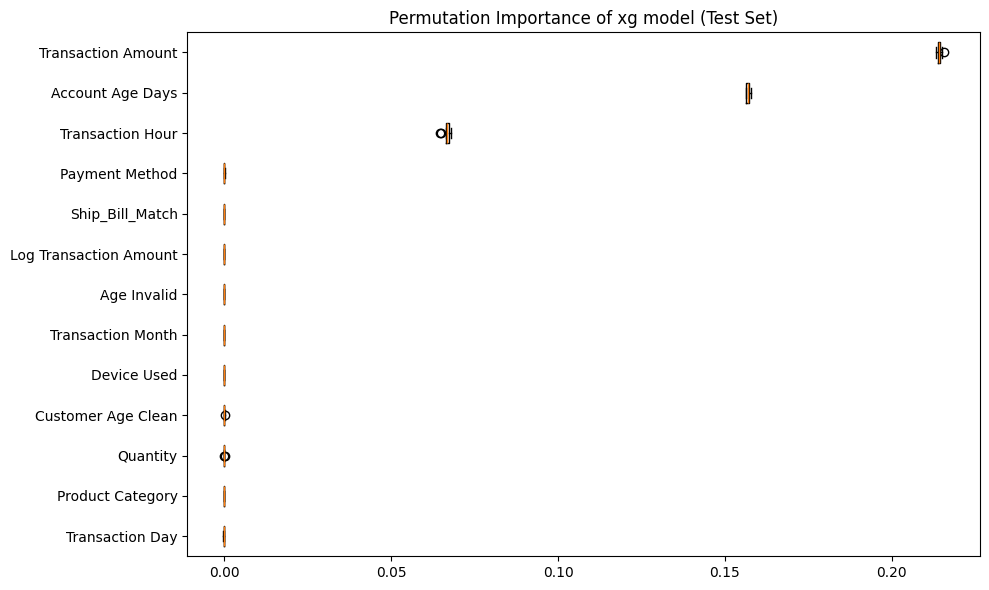

In [ ]:
# Đảm bảo best_dt_model, X_test và y_test được định nghĩa
if 'best_model_xg' in locals() and 'X_test' in locals() and 'y_test' in locals():
# Tính toán Permutation Importance
    result = permutation_importance(
        best_model_xg, X_test, y_test, n_repeats=10,scoring="average_precision", random_state=0, n_jobs=-1
    )
    # Sắp xếp các biến theo mức độ quan trọng
    sorted_idx = result.importances_mean.argsort()
    # Vẽ biểu đồ Permutation Importance
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.boxplot(
        result.importances[sorted_idx].T,
        vert=False,
        tick_labels=X_test.columns[sorted_idx],
    )
    ax.set_title("Permutation Importance of xg model (Test Set)")
    fig.tight_layout()
    plt.show()
else:
    print("Các biến cần thiết (best_xg_model, X_test, y_test) không tìm thấy. Vui lòng chạy các ô trước đó.")

# ỨNG DỤNG MÔ HÌNH

In [ ]:
import os, json, joblib
import pandas as pd

# 1) Fit model cuối (pipeline xgb_under) trên train
xgb_under.fit(X_train, y_train)

# 2) Tạo thư mục lưu
os.makedirs("main", exist_ok=True)

# 3) Lưu pipeline (prep + sampler + xgb)
joblib.dump(xgb_under, "main/fraud_xgb_under_pipeline.joblib")

# 4) Lưu metadata (tên cột + dtype + top categories)
meta = {
    "feature_names": list(X_train.columns),
    "dtypes": {c: str(X_train[c].dtype) for c in X_train.columns},
    "categories": {
        c: X_train[c].dropna().astype(str).value_counts().head(50).index.tolist()
        for c in X_train.columns
        if (str(X_train[c].dtype) == "object") or ("category" in str(X_train[c].dtype))
    }
}

with open("main/metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("✅ Saved:")
print(" - main/fraud_xgb_under_pipeline.joblib")
print(" - main/metadata.json")

✅ Saved:
 - main/fraud_xgb_under_pipeline.joblib
 - main/metadata.json


In [ ]:
import json, joblib
import pandas as pd
import gradio as gr

# Load model + metadata
model = joblib.load("main/fraud_xgb_under_pipeline.joblib")
with open("main/metadata.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

FEATURES = meta["feature_names"]
CATS = meta.get("categories", {})

def _get_path(file_obj):
    if file_obj is None:
        return None
    return file_obj if isinstance(file_obj, str) else getattr(file_obj, "name", None)

def make_template_csv():
    """
    Tạo template CSV đúng cột FEATURES.
    - numeric: để trống
    - categorical: điền giá trị gợi ý đầu tiên nếu có, không thì trống
    """
    row = {}
    for c in FEATURES:
        if c in CATS and len(CATS[c]) > 0:
            row[c] = CATS[c][0]
        else:
            row[c] = ""
    df_tpl = pd.DataFrame([row], columns=FEATURES)
    out_path = "template_fraud_input.csv"
    df_tpl.to_csv(out_path, index=False, encoding="utf-8-sig")
    return out_path


def predict_from_csv_all_rows(file_obj):
    try:
        file_path = _get_path(file_obj)
        if not file_path:
            return {"error": "Bạn chưa upload file CSV."}, None, None

        try:
            df = pd.read_csv(file_path)
        except Exception:
            df = pd.read_csv(file_path, sep=None, engine="python")

        if df.shape[0] == 0:
            return {"error": "CSV rỗng (không có dòng dữ liệu)."}, None, None

        # Chuẩn hóa tên cột (tránh lệch do khoảng trắng)
        df.columns = df.columns.astype(str).str.strip()

        # Check thiếu/dư cột
        missing = [c for c in FEATURES if c not in df.columns]
        extra = [c for c in df.columns if c not in FEATURES]
        if missing:
            return {
                "error": "CSV thiếu cột bắt buộc (có thể do sai tên cột hoặc dư khoảng trắng).",
                "missing_columns": missing[:80],
                "missing_count": len(missing),
                "extra_columns_found": extra[:80],
                "note": "Hãy dùng nút Download template CSV để lấy đúng schema."
            }, None, None

        # Lấy toàn bộ X theo đúng schema
        X = df[FEATURES].copy()

        # Chuẩn hoá rỗng: "" hoặc "   " -> NA
        X = X.replace(r"^\s*$", pd.NA, regex=True)

        # categorical rỗng -> "unknown"
        for c in CATS.keys():
            if c in X.columns:
                X[c] = X[c].astype("string").fillna("unknown")

        # Predict tất cả dòng
        proba = model.predict_proba(X)[:, 1]
        pred = model.predict(X)

        out_df = df.copy()
        out_df["fraud_probability"] = proba
        out_df["prediction"] = np.where(pred == 1, "FRAUD ⚠️", "NOT FRAUD ✅")
        out_df["flagged"] = (pred == 1)

        # Lưu file kết quả để download
        out_path = "predictions_output.csv"
        out_df.to_csv(out_path, index=False, encoding="utf-8-sig")

        summary = {
            "rows_in_csv": int(df.shape[0]),
            "flagged_count": int((pred == 1).sum()),
            "flagged_rate": float((pred == 1).mean()),
            "mean_fraud_probability": float(proba.mean()),
            "extra_columns_in_csv": extra[:80],
            "extra_count": len(extra),
            "note": "prediction dùng threshold mặc định 0.5 (model.predict())"
        }

        preview_df = out_df[FEATURES + ["fraud_probability", "prediction", "flagged"]].head(20)
        preview = {
            "columns": list(preview_df.columns),
            "rows": preview_df.fillna("").astype(str).to_dict(orient="records")
        }

        return summary, preview, out_path

    except Exception as e:
        # Trả lỗi ra JSON để thấy rõ nguyên nhân
        return {"error": str(e)}, None, None


with gr.Blocks() as demo:
    gr.Markdown("# Fraud Detection Demo (XGB_Under) — Upload CSV (Predict ALL rows)")
    gr.Markdown("1) Tải template CSV → 2) điền nhiều dòng → 3) upload → dự đoán **tất cả dòng** và tải file kết quả.")

    with gr.Row():
        with gr.Column():
            btn_tpl = gr.Button("Download template CSV")
            file_tpl = gr.File(label="Template file", interactive=False)
        with gr.Column():
            file_in = gr.File(label="Upload CSV")
            btn_pred = gr.Button("Predict ALL rows")
            summary_out = gr.JSON(label="Summary")
            preview_out = gr.JSON(label="Preview (top 20 rows)")
            file_out = gr.File(label="Download predictions_output.csv", interactive=False)

    btn_tpl.click(fn=make_template_csv, inputs=None, outputs=file_tpl)
    btn_pred.click(fn=predict_from_csv_all_rows, inputs=[file_in], outputs=[summary_out, preview_out, file_out])

demo.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://8bbb99640ab60978f4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://8bbb99640ab60978f4.gradio.live


# PHÂN TÍCH GIẢM THIỂU RỦI RO TỔN THẤT — MÔ HÌNH XGB_UNDER

In [42]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# ===============================
# 1) Train lại mô hình xgb_under
# ===============================
xgb_under.fit(X_train, y_train)

# ===============================
# 2) Predict trên tập test
# ===============================
y_pred = xgb_under.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# ===============================
# 3) Chuẩn bị cột số tiền giao dịch cho test
# ===============================
if isinstance(X_test, pd.DataFrame) and 'Transaction Amount' in X_test.columns:
    amount_test = pd.to_numeric(X_test['Transaction Amount'], errors='coerce').fillna(0)
elif isinstance(X_test, pd.DataFrame) and 'Log Transaction Amount' in X_test.columns:
    amount_test = np.expm1(pd.to_numeric(X_test['Log Transaction Amount'], errors='coerce')).clip(lower=0).fillna(0)
elif 'df_model' in globals() and isinstance(X_test, pd.DataFrame):
    amount_test = pd.to_numeric(df_model.loc[X_test.index, 'Transaction Amount'], errors='coerce').fillna(0)
else:
    raise ValueError("Không tìm thấy cột Transaction Amount để tính tổn thất.")

# ===============================
# 4) Định nghĩa chi phí tổn thất do dự đoán sai
# ===============================
# FN (fraud thật nhưng dự đoán không fraud): mất toàn bộ số tiền giao dịch
# FP (không fraud nhưng dự đoán fraud): chi phí xử lý/review thủ công, giả định 2% số tiền
fp_review_rate = 0.02

mask_fn = (y_test.values == 1) & (y_pred == 0)
mask_fp = (y_test.values == 0) & (y_pred == 1)

loss_fn = amount_test[mask_fn].sum()
loss_fp = (amount_test[mask_fp] * fp_review_rate).sum()
total_loss = loss_fn + loss_fp

# baseline: không dùng mô hình => toàn bộ giao dịch fraud bị mất
fraud_mask = (y_test.values == 1)
baseline_loss = amount_test[fraud_mask].sum()

risk_reduction_abs = baseline_loss - total_loss
risk_reduction_pct = (risk_reduction_abs / baseline_loss * 100) if baseline_loss > 0 else 0

# ===============================
# 5) Báo cáo kết quả
# ===============================
summary = pd.DataFrame({
    'Metric': [
        'TN', 'FP', 'FN', 'TP',
        'FN_Loss', 'FP_Loss', 'Total_Loss',
        'Baseline_Loss_No_Model',
        'Absolute_Risk_Reduction',
        'Risk_Reduction_%'
    ],
    'Value': [
        tn, fp, fn, tp,
        float(loss_fn), float(loss_fp), float(total_loss),
        float(baseline_loss),
        float(risk_reduction_abs),
        float(risk_reduction_pct)
    ]
})

display(summary)

print(f"FN loss (mất do bỏ lọt fraud): {loss_fn:,.2f}")
print(f"FP loss (chi phí review false alarm): {loss_fp:,.2f}")
print(f"Total loss khi dùng mô hình: {total_loss:,.2f}")
print(f"Baseline loss nếu không dùng mô hình: {baseline_loss:,.2f}")
print(f"Giảm thiểu rủi ro tuyệt đối: {risk_reduction_abs:,.2f}")
print(f"Tỷ lệ giảm thiểu rủi ro: {risk_reduction_pct:.2f}%")

,Metric,Value
0,TN,2.220440e+05
1,FP,5.786000e+04
2,FN,4.577000e+03
3,TP,1.011000e+04
4,FN_Loss,8.678382e+05
5,FP_Loss,3.917831e+05
6,Total_Loss,1.259621e+06
7,Baseline_Loss_No_Model,8.070789e+06
8,Absolute_Risk_Reduction,6.811168e+06
9,Risk_Reduction_%,8.439284e+01


FN loss (mất do bỏ lọt fraud): 867,838.19
FP loss (chi phí review false alarm): 391,783.13
Total loss khi dùng mô hình: 1,259,621.32
Baseline loss nếu không dùng mô hình: 8,070,789.43
Giảm thiểu rủi ro tuyệt đối: 6,811,168.11
Tỷ lệ giảm thiểu rủi ro: 84.39%
